In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# ds = xr.open_dataset('/u/ganzhang/shield/idealized_BCmoist'+ '/' + 'atmos_daily' + '.tile' + str(1) + '.nc', decode_times=False)
# ds['PWAT'].min()
# levels = np.linspace(-0.04, 0.04, 21)
# levels[levels != 0]

In [2]:
levels_omg = np.linspace(-0.4, 0.4, 21)
levels_vort = np.linspace(-10, 10, 21)*10**-5


levels_dict = {'omg500': levels_omg[levels_omg != 0],
               'PWAT': np.linspace(10, 100, 19),
               'PRESsfc': np.linspace(900, 1020, 21)*100,
               'vort850': levels_vort[levels_vort != 0]}

cmap_dict =  {'omg500': 'BrBG_r',
               'PWAT': 'Blues',
               'PRESsfc': 'Reds',
               'vort850': 'RdBu_r'}

def plot_tiles(path, file, target_time, var_list=('omg500', 'PWAT')):
    fig, ax = plt.subplots(3, 2, figsize=(10, 10))
    for itile in range(6):
        ax_target = ax[itile//2, itile%2]
        ds = xr.open_dataset(path + '/' + file+ '.tile' + str(itile+1) + '.nc', decode_times=False)
        # ds['VORT850'].isel(time=it).plot(ax=ax_target)

        ds[var_list[0]].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Tile ' + str(itile) + ' Day=' + str(ds['time'].isel(time=target_time).values))
        ax_target.set_xlabel('')
        ax_target.set_ylabel('')

    plt.subplots_adjust(hspace=0.3)

def plot_regridded(path, file, target_time, var_list=('omg500', 'PWAT'), zoom=True, lat_lon_bounds=(10, 70, 60, 240)):
    ds = xr.open_dataset(path + '/' + file + '.nc', decode_times=False)

    if zoom:
        fig, ax = plt.subplots(2, 1, figsize=(10, 10))
        ax_target = ax[0]
        ds[var_list[0]].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Moist Baroclinic Wave, Day=' + str(ds['time'].isel(time=target_time).values))


        ax_target = ax[1]
        ds[var_list[0]].isel(time=target_time).sel(grid_yt=slice(lat_lon_bounds[0],lat_lon_bounds[1]), \
                                                   grid_xt=slice(lat_lon_bounds[2],lat_lon_bounds[3])).\
            plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).sel(grid_yt=slice(lat_lon_bounds[0],lat_lon_bounds[1]), \
                                                   grid_xt=slice(lat_lon_bounds[2],lat_lon_bounds[3])).\
            plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Zoom, Day=' + str(ds['time'].isel(time=target_time).values))

    else:
        fig, ax_target = plt.subplots(1, 1, figsize=(10, 5))
        ds[var_list[0]].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Moist Baroclinic Wave, Day=' + str(ds['time'].isel(time=target_time).values))


def plot_regridded_plev(path, file, target_time, var_list=('PRESsfc', 'PWAT'), zoom=True, lat_lon_bounds=(10, 70, 60, 240)):
    ds = xr.open_dataset(path + '/' + file + '.nc', decode_times=False)

    if zoom:
        fig, ax = plt.subplots(2, 1, figsize=(10, 10))
        ax_target = ax[0]
        ds[var_list[0]].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Moist Baroclinic Wave, Day=' + str(ds['time'].isel(time=target_time).values))


        ax_target = ax[1]
        ds[var_list[0]].isel(time=target_time).sel(grid_yt=slice(lat_lon_bounds[0],lat_lon_bounds[1]), \
                                                   grid_xt=slice(lat_lon_bounds[2],lat_lon_bounds[3])).\
            plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).sel(grid_yt=slice(lat_lon_bounds[0],lat_lon_bounds[1]), \
                                                   grid_xt=slice(lat_lon_bounds[2],lat_lon_bounds[3])).\
            plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Zoom, Day=' + str(ds['time'].isel(time=target_time).values))

    else:
        fig, ax_target = plt.subplots(1, 1, figsize=(10, 2.5))
        ds[var_list[0]].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]])
        ds[var_list[1]].isel(time=target_time).plot.contourf(ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]])
        # ds['PRESsfc'].isel(time=target_time).plot.contour(ax=ax_target, levels=levels_pres, c='k')
        ax_target.set_title('Moist Baroclinic Wave, Day=' + str(ds['time'].isel(time=target_time).values))

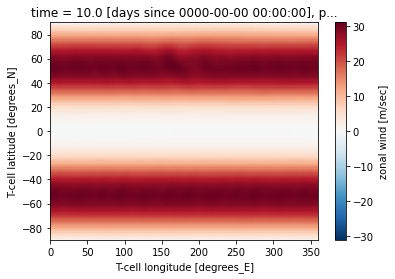

In [3]:
ds = xr.open_dataset('./atmos_daily.nc', decode_times=False)
ds['u_plev'].isel(time=9, plev=0).plot()

In [4]:
# Filter the dataset for time = 8.0
time_filtered = ds.sel(time=8.0)

# Compute and print the minimum PRESsfc
min_PRESSfc = time_filtered.PRESsfc.min().values
print("Minimum PRESsfc at time = 8.0:", min_PRESSfc)

# Compute and print the maximum VORT850
max_VORT850 = time_filtered.VORT850.max().values
print("Maximum VORT850 at time = 8.0:", max_VORT850)

# Compute and print the maximum VORT500
max_VORT500 = time_filtered.VORT500.max().values
print("Maximum VORT500 at time = 8.0:", max_VORT500)

Minimum PRESsfc at time = 8.0: 94749.65625
Maximum VORT850 at time = 8.0: 0.0002554630918893963
Maximum VORT500 at time = 8.0: 5.4645999625790864e-05


In [5]:
ds

<xarray.Dataset>
Dimensions:       (time: 15, grid_yt: 180, bnds: 2, grid_xt: 360, plev: 15)
Coordinates:
  * time          (time) float32 1.0 2.0 3.0 4.0 5.0 ... 12.0 13.0 14.0 15.0
  * grid_yt       (grid_yt) float32 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * grid_xt       (grid_xt) float32 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * plev          (plev) float32 10.0 50.0 100.0 150.0 ... 925.0 975.0 1e+03
Dimensions without coordinates: bnds
Data variables:
    grid_yt_bnds  (grid_yt, bnds) float32 ...
    grid_xt_bnds  (grid_xt, bnds) float32 ...
    PWAT          (time, grid_yt, grid_xt) float32 ...
    h_plev        (time, plev, grid_yt, grid_xt) float32 ...
    u_plev        (time, plev, grid_yt, grid_xt) float32 ...
    v_plev        (time, plev, grid_yt, grid_xt) float32 ...
    t_plev        (time, plev, grid_yt, grid_xt) float32 ...
    PRESsfc       (time, grid_yt, grid_xt) float32 ...
Attributes:
    NumFilesInSet:  1
    title:          C96.64bit
    grid_type:      regular
    grid_tile:      N/A
    history:        /opt/ufs-srweather-app/container-bin/fregrid --input_mosa...
    code_version:   $Name: bronx-10_performance_z1l $

In [1]:
import xarray as xa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, cm, colors
import cartopy.crs as ccrs
import colorsys
import dask #Chunking will be necessary for the larger datasets

Text(0.5, 1.0, '(b) time = 8.0 day, plev = 1000 hPa')

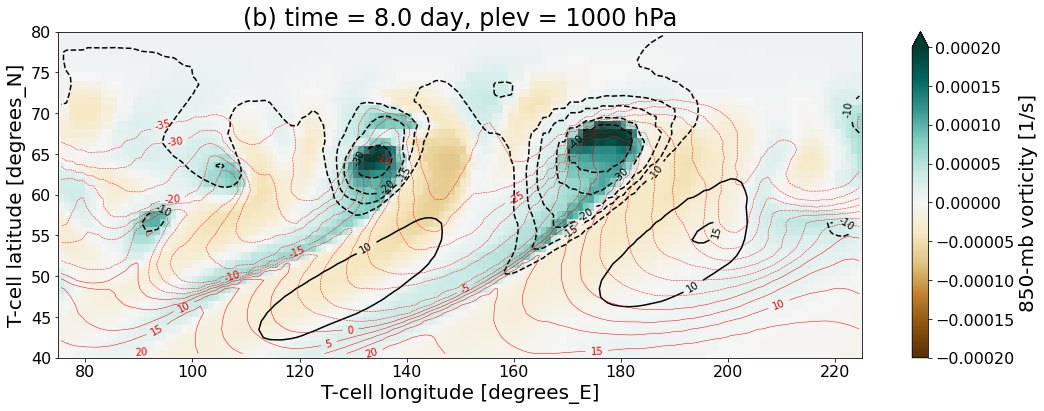

In [3]:
large = 24; med = 20; small = 16
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (14, 6),
          'axes.labelsize': med,
          'axes.titlesize': large,
          'xtick.labelsize': small,
          'ytick.labelsize': small,
          'figure.titlesize': large,
          'axes.titlepad': 6}
plt.rcParams.update(params)

xamoist=xa.open_dataset("./atmos_daily.nc",decode_times=False,chunks={'time': 1})

pr_clevs=(-40,-30,-20,-15,-10,10,15,20)
t_clevs=np.arange(-35,26,5)


fig=plt.figure(figsize=(18,6))
datime=xamoist.sel(time=8,grid_yt=slice(40,80),grid_xt=slice(75,225))
datime.VORT850.plot(ax=fig.gca(),vmax=2e-4,vmin=-2e-4,cmap=cm.get_cmap("BrBG"))
cb=(datime.PRESsfc/100.-1000).plot.contour(ax=fig.gca(),colors='k',levels=pr_clevs)
fig.gca().clabel(cb,cb.levels,fmt='%d')
cb=(datime.t_plev.sel(plev=1000)-273.14).plot.contour(ax=fig.gca(),colors='r',linewidths=0.5,levels=t_clevs)
fig.gca().clabel(cb,cb.levels,fmt='%d')
fig.gca().set_title("(b) time = 8.0 day, plev = 1000 hPa",fontsize=large)


[[ 6.2353706  6.2417374  6.2466507 ...  6.260704   6.2695427  6.2603416]
 [ 5.9975243  5.9979057  5.998291  ...  6.045372   6.049999   6.049122 ]
 [ 5.7675896  5.7681656  5.768276  ...  5.818592   5.8133583  5.824642 ]
 ...
 [-5.4496    -5.4544487 -5.45269   ... -5.408539  -5.3948402 -5.402725 ]
 [-5.651581  -5.650196  -5.6485558 ... -5.617687  -5.6200447 -5.599823 ]
 [-5.832821  -5.831295  -5.829769  ... -5.76173   -5.768448  -5.781025 ]]


Text(0.5, 1.0, '(b) time = 8.0 day, plev = 500 hPa')

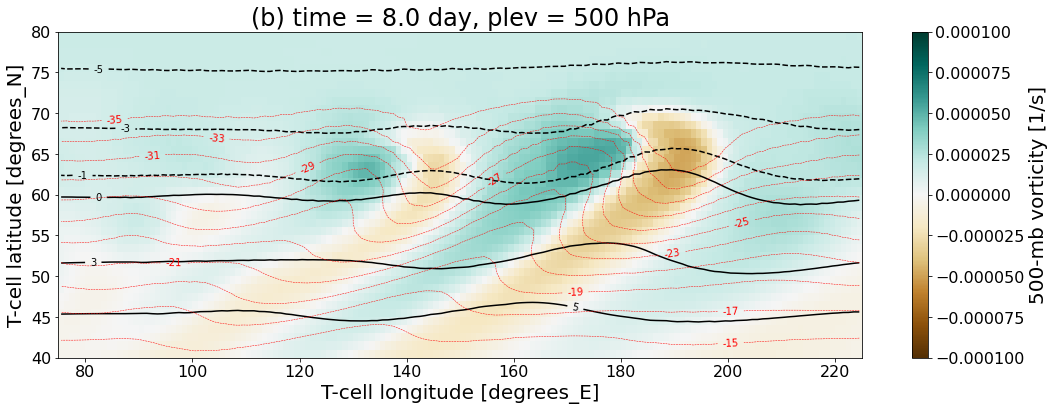

In [4]:
large = 24; med = 20; small = 16
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (14, 6),
          'axes.labelsize': med,
          'axes.titlesize': large,
          'xtick.labelsize': small,
          'ytick.labelsize': small,
          'figure.titlesize': large,
          'axes.titlepad': 6}
plt.rcParams.update(params)

xamoist=xa.open_dataset("./atmos_daily.nc",decode_times=False,chunks={'time': 1})

pr_clevs=(-10,-5,-3,-1,0,3,5,10)
t_clevs=np.arange(-35,26,2)


fig=plt.figure(figsize=(18,6))
datime=xamoist.sel(time=8,grid_yt=slice(40,80),grid_xt=slice(75,225))

print((datime.h_plev.sel(plev=500)/100.-50).values)
datime.VORT500.plot(ax=fig.gca(),vmax=1e-4,vmin=-1e-4,cmap=cm.get_cmap("BrBG"))
cb=(datime.h_plev.sel(plev=500)/100.-50).plot.contour(ax=fig.gca(),colors='k',levels=pr_clevs)
fig.gca().clabel(cb,cb.levels,fmt='%d')
cb=(datime.t_plev.sel(plev=500)-273.14).plot.contour(ax=fig.gca(),colors='r',linewidths=0.5,levels=t_clevs)
fig.gca().clabel(cb,cb.levels,fmt='%d')
fig.gca().set_title("(b) time = 8.0 day, plev = 500 hPa")

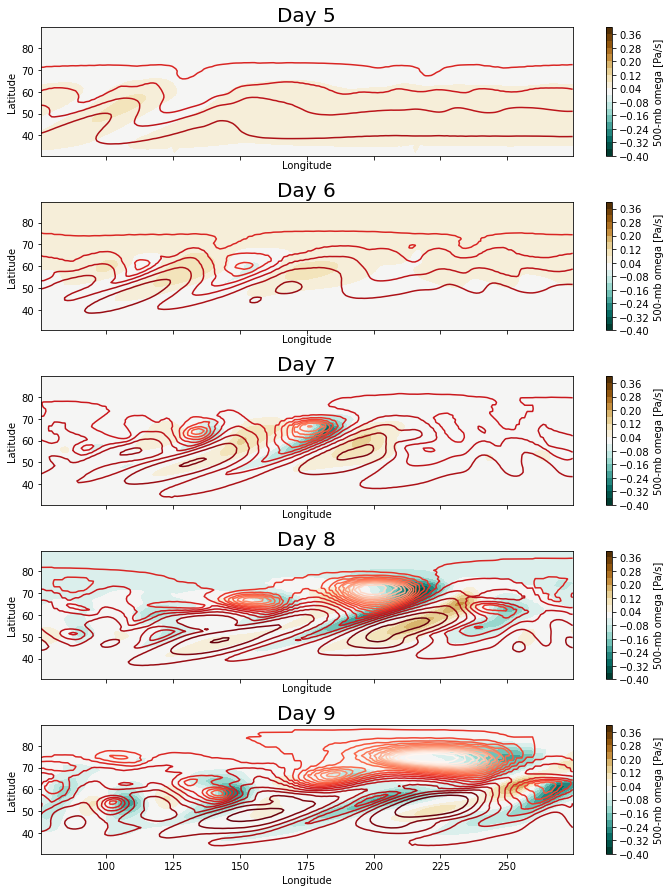

"\n# Call the updated function\nplot_days_5_to_9_vertical('./', 'atmos_daily', var_list=('PRESsfc', 'omg500'))\n"

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Define levels and colormap dictionaries
levels_omg = np.linspace(-0.4, 0.4, 21)
levels_vort = np.linspace(-10, 10, 21) * 10**-5

levels_dict = {
    'omg500': levels_omg[levels_omg != 0],
    'PWAT': np.linspace(10, 100, 19),
    'PRESsfc': np.linspace(900, 1020, 21) * 100,
    'vort850': levels_vort[levels_vort != 0]
}

cmap_dict = {
    'omg500': 'BrBG_r',
    'PWAT': 'Blues',
    'PRESsfc': 'Reds',
    'vort850': 'RdBu_r'
}
'''
def plot_days_5_to_9_vertical(path, file, var_list=('omg500', 'PWAT')):
    # Create a vertical layout with 5 rows and 1 column
    fig, ax = plt.subplots(5, 1, figsize=(10, 12.5), sharex=True, sharey=True)
    
    for i, day in enumerate(range(5, 10)):
        ds = xr.open_dataset(f"{path}/{file}.nc", decode_times=False)
        
        ax_target = ax[i]
        ds[var_list[0]].isel(time=day).plot.contour(
            ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]]
        )
        ds[var_list[1]].isel(time=day).plot.contourf(
            ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]]
        )
        ax_target.set_title(f"Day {day}")
        ax_target.set_ylabel('Latitude')
        ax_target.set_xlabel('Longitude')

    plt.tight_layout()
    plt.show()

'''
def plot_days_5_to_9_vertical(path, file, var_list=('omg500', 'PWAT')):
    # Create a vertical layout with 5 rows and 1 column
    fig, ax = plt.subplots(5, 1, figsize=(10, 12.5), sharex=True, sharey=True)
    
    for i, day in enumerate(range(5, 10)):
        ds = xr.open_dataset(f"{path}/{file}.nc", decode_times=False)
        
        ax_target = ax[i]
        ds[var_list[0]].isel(time=day,grid_yt=slice(30+90,90+90),grid_xt=slice(75,275)).plot.contour(
            ax=ax_target, levels=levels_dict[var_list[0]], cmap=cmap_dict[var_list[0]]
        )
        ds[var_list[1]].isel(time=day,grid_yt=slice(30+90,90+90),grid_xt=slice(75,275)).plot.contourf(
            ax=ax_target, levels=levels_dict[var_list[1]], cmap=cmap_dict[var_list[1]]
        )
        ax_target.set_title(f"Day {day}", fontsize = 20)
        ax_target.set_ylabel('Latitude')
        ax_target.set_xlabel('Longitude')

    plt.tight_layout()
    plt.show()

# Call the updated function
plot_days_5_to_9_vertical('./', 'atmos_daily', var_list=('PRESsfc', 'omg500'))
'''
# Call the updated function
plot_days_5_to_9_vertical('./', 'atmos_daily', var_list=('PRESsfc', 'omg500'))
'''

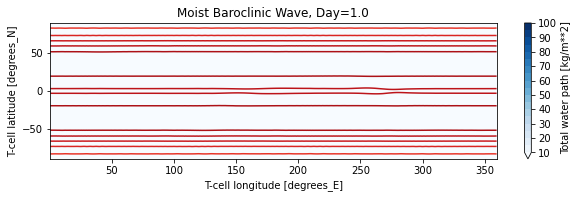

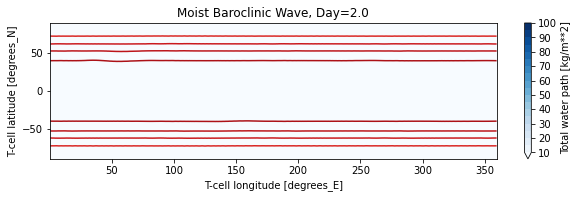

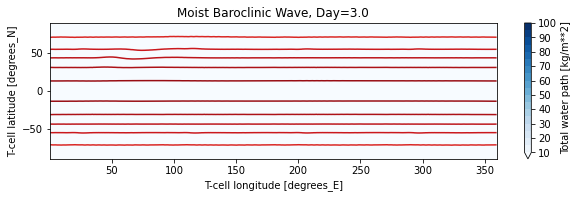

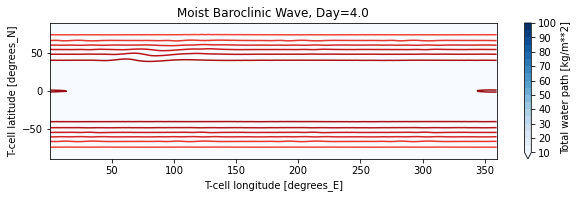

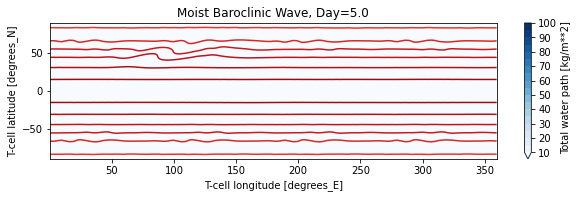

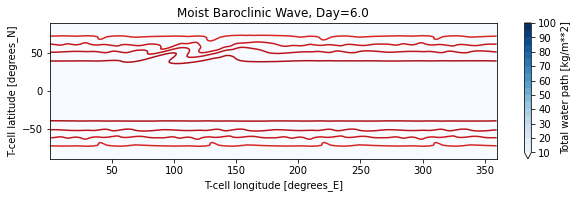

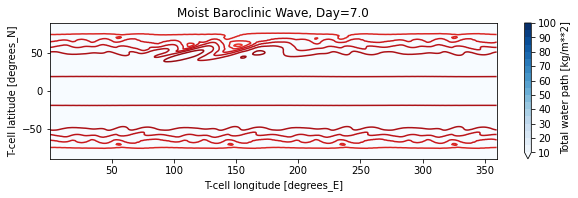

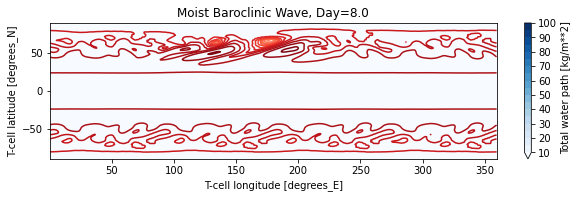

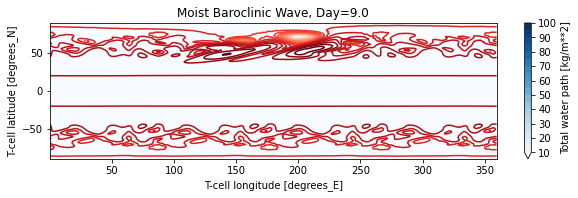

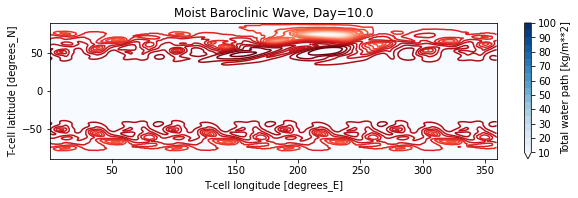

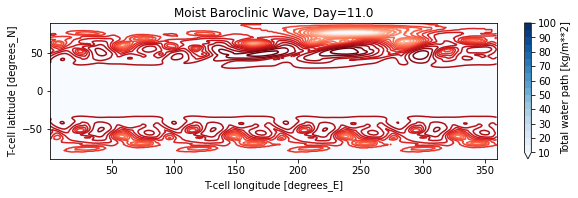

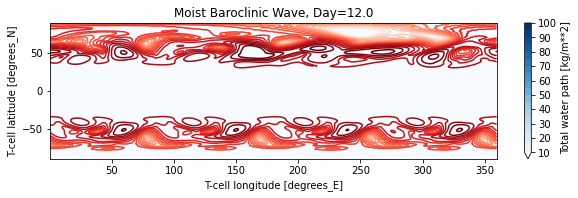

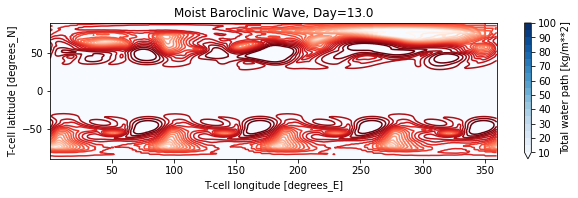

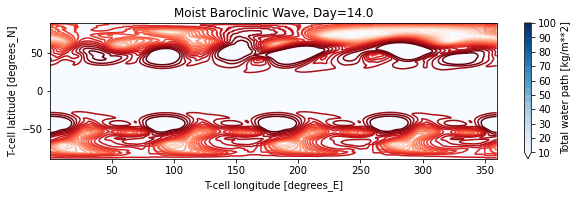

In [4]:
for it in range(0,14, 1):
    plot_regridded_plev('./', 'atmos_daily', it, zoom=False)

KeyError: 'omg500'

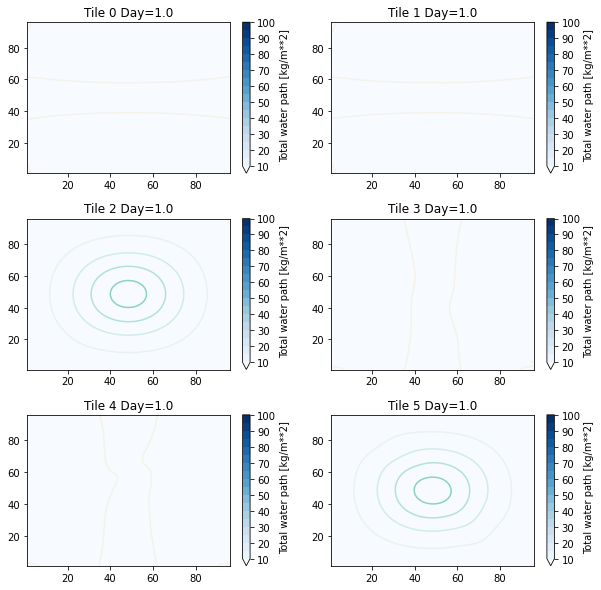

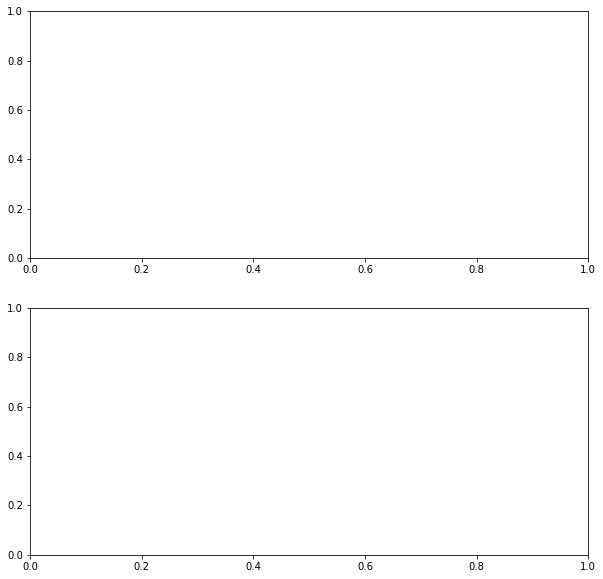

In [7]:
for it in range(0,1):
    plot_tiles('./', 'atmos_daily', it)
    plot_regridded('./', 'atmos_daily', it)

In [8]:
# it = 3
# fig, ax = plt.subplots(3, 2, figsize=(10, 10))
# for itile in range(6):
#     ax_target = ax[itile//2, itile%2]
#     ds = xr.open_dataset('/u/ganzhang/shield/idealized_test/atmos_daily.tile' + str(itile+1) + '.nc', decode_times=False)
#     # ds['VORT850'].isel(time=it).plot(ax=ax_target)
#     ds['omg500'].isel(time=it).plot(ax=ax_target)
#     ds['PRESsfc'].isel(time=it).plot.contour(ax=ax_target)
#     ax_target.set_title('Tile ' + str(itile) + ' Day=' + str(it))
#     ax_target.set_xlabel('')
#     ax_target.set_ylabel('')

# plt.subplots_adjust(hspace=0.3)

In [9]:
# ds_regrid = xr.open_dataset('/u/ganzhang/shield/idealized_test/atmos_daily.nc', decode_times=False)
# ds_regrid
# ds_regrid['omg500'].isel(time=it).plot()
# ds_regrid['PRESsfc'].isel(time=it).plot.contour()
# plt.title('Moist Baroclinic Wave, Day=' + str(ds_regrid['time'].isel(time=3).values))

KeyError: 'VORT850'

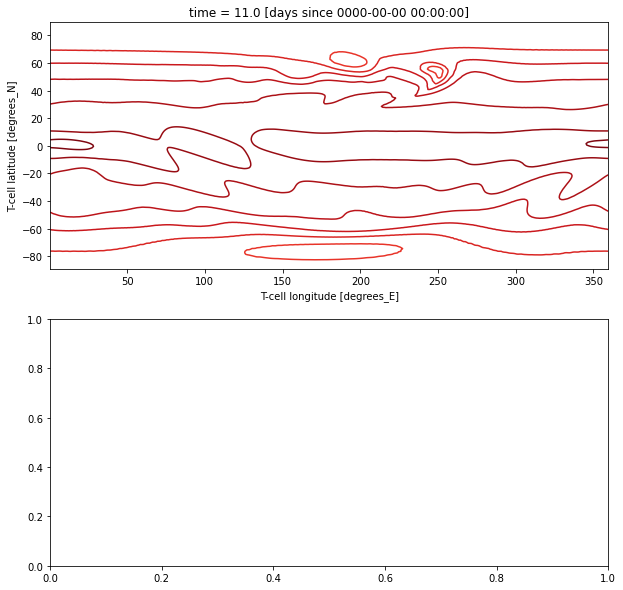

In [8]:
for it in [0, 4, 8, 12, 16, 19]:
    #plot_tiles('./', 'atmos_daily', it, var_list=('PRESsfc', 'VORT850'))
    plot_regridded('./', 'atmos_daily', it, var_list=('PRESsfc', 'VORT850'), zoom=True, lat_lon_bounds=(10, 40, 150, 180))

In [4]:
ds = xr.open_dataset('./atmos_daily.tile' + str(1) + '.nc', decode_times=False)
ds

<xarray.Dataset>
Dimensions:     (grid_xt: 96, grid_yt: 96, plev: 15, time: 0)
Coordinates:
  * grid_xt     (grid_xt) float32 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0
  * grid_yt     (grid_yt) float32 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0
  * plev        (plev) float32 10.0 50.0 100.0 150.0 ... 850.0 925.0 975.0 1e+03
  * time        (time) float32 
Data variables: (12/21)
    h_plev      (time, plev, grid_yt, grid_xt) float32 ...
    u_plev      (time, plev, grid_yt, grid_xt) float32 ...
    v_plev      (time, plev, grid_yt, grid_xt) float32 ...
    t_plev      (time, plev, grid_yt, grid_xt) float32 ...
    q_plev      (time, plev, grid_yt, grid_xt) float32 ...
    omg_plev    (time, plev, grid_yt, grid_xt) float32 ...
    ...          ...
    PRESsfc     (time, grid_yt, grid_xt) float32 ...
    PRESctp     (time, grid_yt, grid_xt) float32 ...
    TMP500_300  (time, grid_yt, grid_xt) float32 ...
    acl         (time, grid_yt, grid_xt) float32 ...
    acl2        (time, grid_yt, grid_xt) float32 ...
    acly        (time, grid_yt, grid_xt) float32 ...
Attributes:
    NumFilesInSet:  1
    title:          C96.64bit
    grid_type:      regular
    grid_tile:      N/A

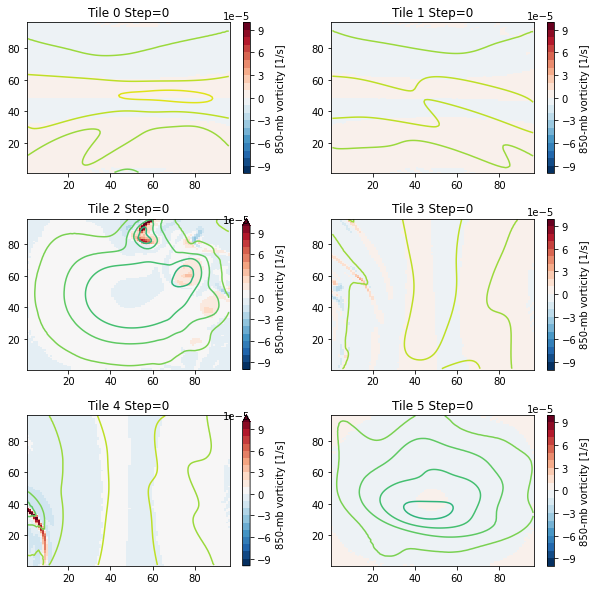

In [9]:
it = 0
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
for itile in range(6):
    ax_target = ax[itile//2, itile%2]
    ds = xr.open_dataset('./atmos_daily.tile' + str(itile+1) + '.nc', decode_times=False)
    # ds['VORT850'].isel(time=it).plot(ax=ax_target)
    ds['VORT850'].isel(time=it).plot(ax=ax_target, levels=np.linspace(-10, 10, 21)*10**-5)
    ds['PRESsfc'].isel(time=it).plot.contour(ax=ax_target, levels=np.linspace(900, 1020, 21)*100)
    ax_target.set_title('Tile ' + str(itile) + ' Step=' + str(it))
    ax_target.set_xlabel('')
    ax_target.set_ylabel('')

plt.subplots_adjust(hspace=0.3)

In [71]:
# ds_regrid = xr.open_dataset('/u/ganzhang/shield/idealized_TC/atmos_4xdaily.nc', decode_times=False)
# ds_regrid

# it = 0
# ds_regrid['vort850'].isel(time=it).plot()
# ds_regrid['PRESsfc'].isel(time=it).plot.contour()
# plt.title('Tropical Cyclone, Step=' + str(ds_regrid['time'].isel(time=it).values))